In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

df = pd.read_csv('content/TSLA.csv')
df



,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [2]:
df.shape


(2956, 7)

In [3]:

df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,1229.910034,3.046940e+08


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


<function matplotlib.pyplot.show(close=None, block=None)>

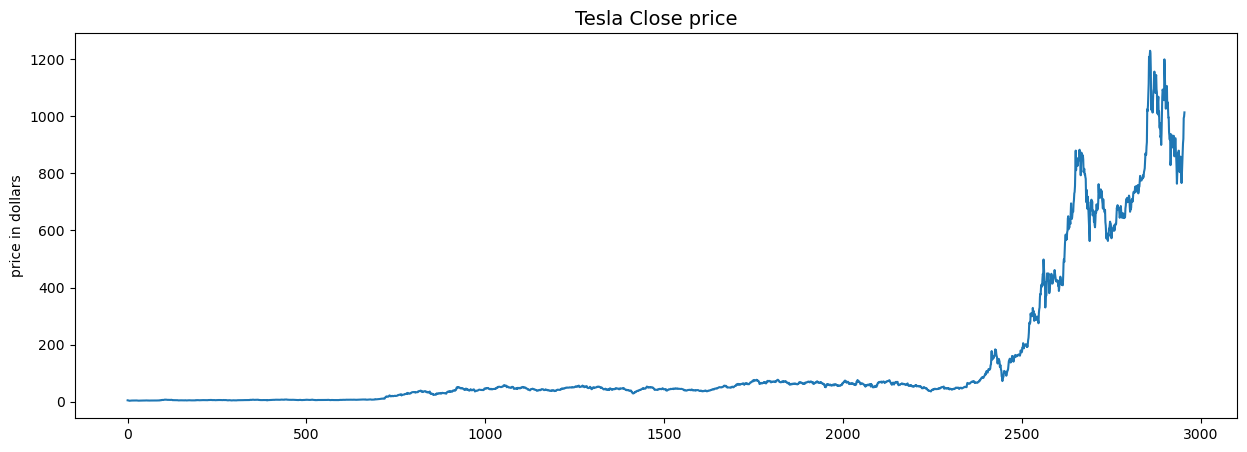

In [5]:
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title('Tesla Close price', fontsize=14)
plt.ylabel('price in dollars')
plt.show

In [6]:
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [7]:
df[df['Close'] == df['Adj Close']].shape

(2956, 7)

In [8]:
df = df.drop(['Adj Close'], axis=1)

In [9]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

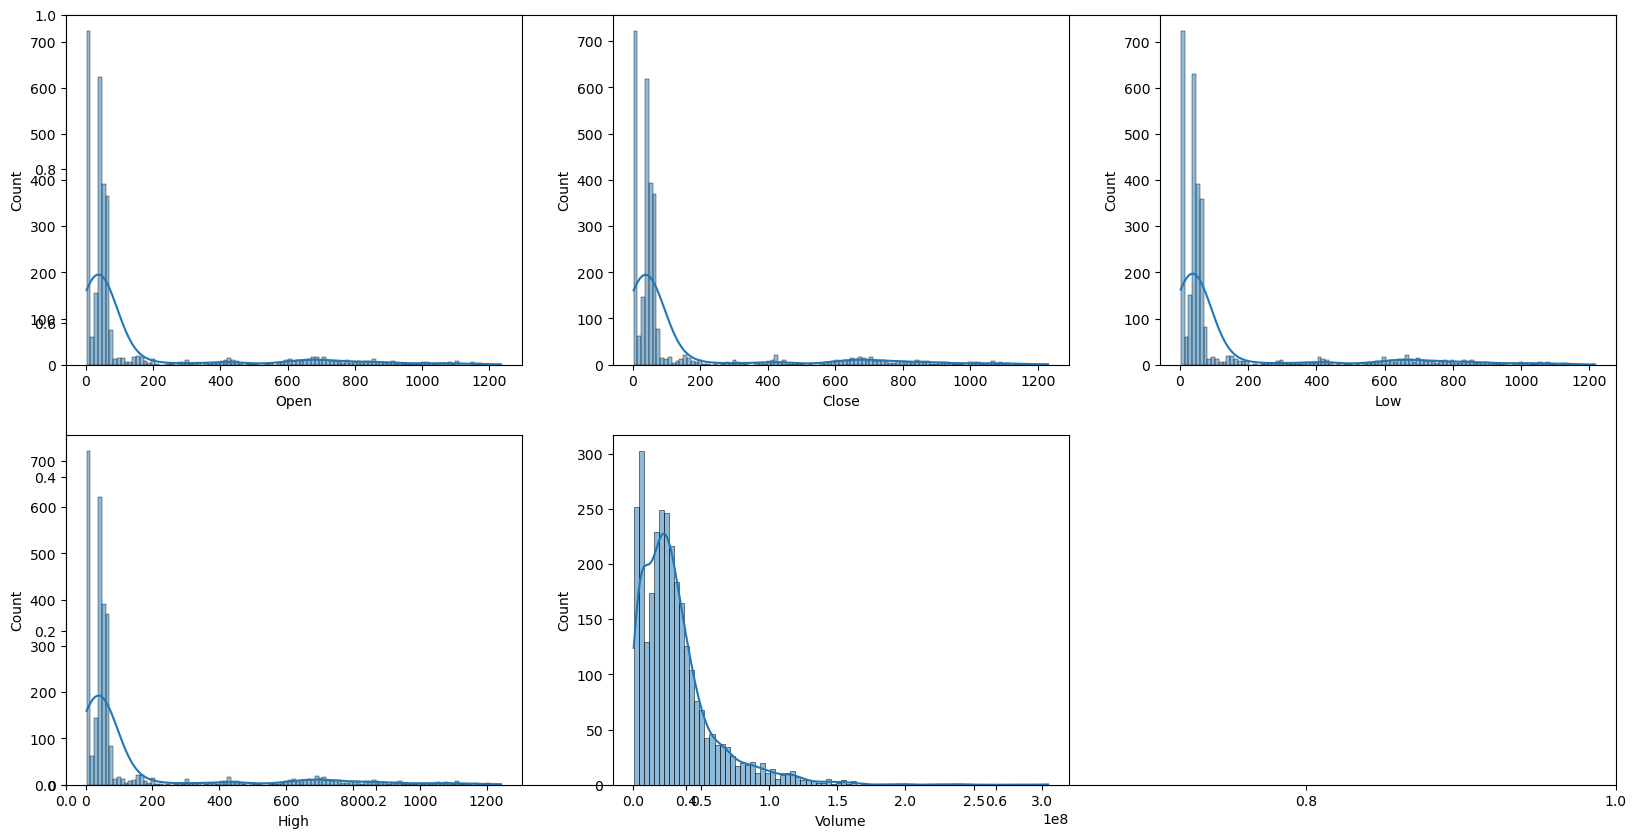

In [10]:
features = ['Open', 'Close', 'Low', 'High', 'Volume']

plt.subplots(figsize=(20,10))
for i , col in enumerate(features):
    plt.subplot(2,3, i+1)
    sb.histplot(df[col], kde=True)

plt.show()

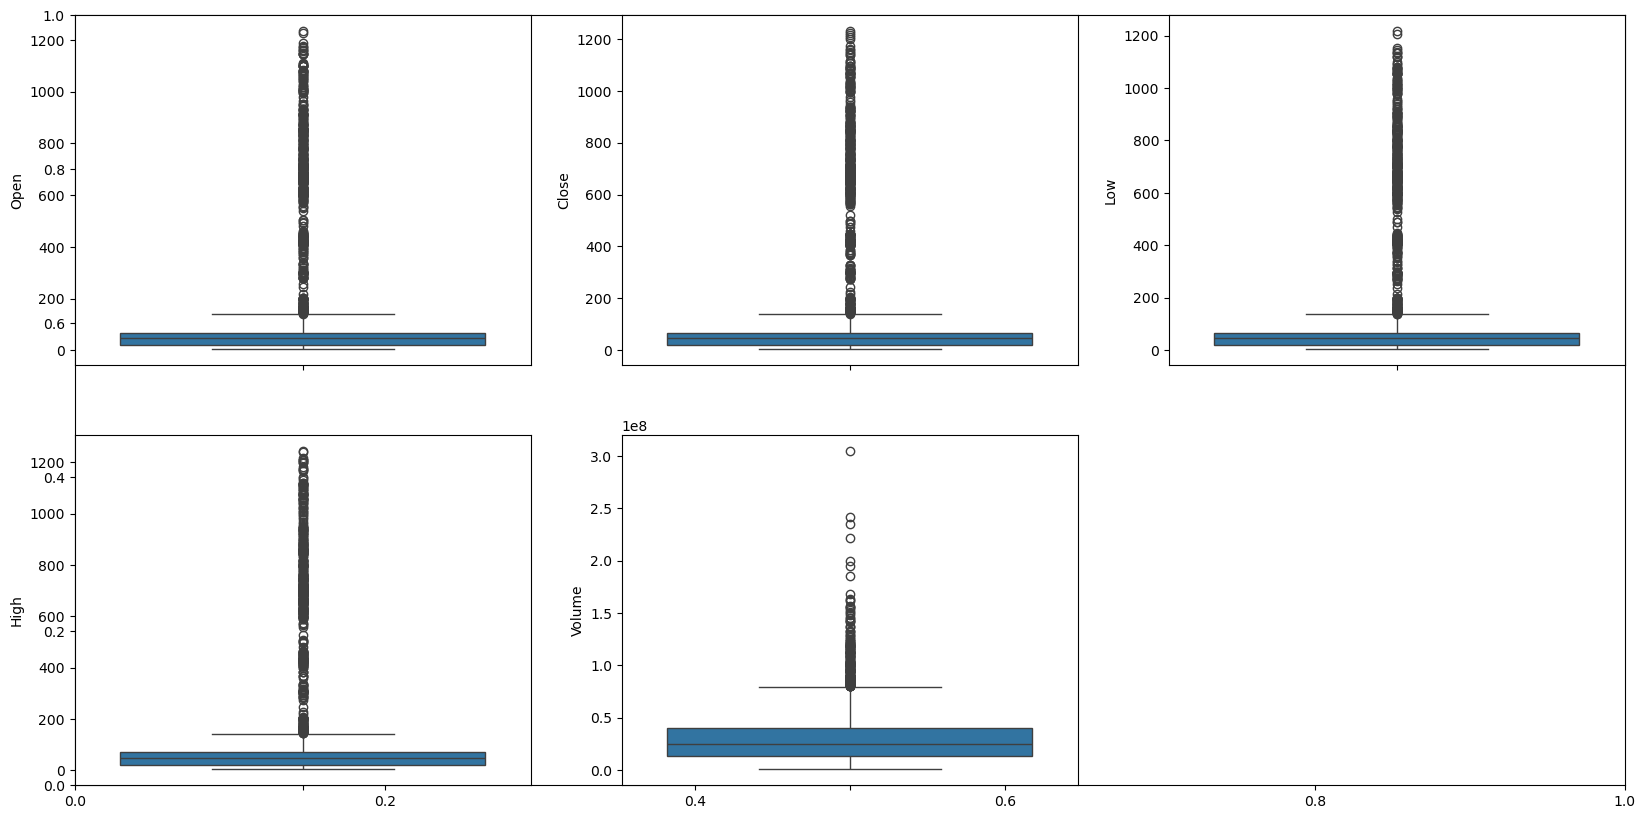

In [11]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
    plt.subplot(2,3, i+1)
    sb.boxplot(df[col])
plt.show()


In [12]:
#from the above data we can conclude that that volume data contains outliers but the others are just fine 

In [13]:
splitted = df['Date'].str.split('-', expand=True)

df['day'] = splitted[2].astype('int')
df['month'] = splitted[1].astype('int')
df['year'] = splitted[0].astype('int')

df.head()

,Date,Open,High,Low,Close,Volume,day,month,year
0,2010-06-29,3.800,5.000,3.508,4.778,93831500,29,6,2010
1,2010-06-30,5.158,6.084,4.660,4.766,85935500,30,6,2010
2,2010-07-01,5.000,5.184,4.054,4.392,41094000,1,7,2010
3,2010-07-02,4.600,4.620,3.742,3.840,25699000,2,7,2010
4,2010-07-06,4.000,4.000,3.166,3.222,34334500,6,7,2010


In [14]:
df['is_quaterly_end'] = np.where(df['month']%3==0,1,0)
df.head()

,Date,Open,High,Low,Close,Volume,day,month,year,is_quaterly_end
0,2010-06-29,3.800,5.000,3.508,4.778,93831500,29,6,2010,1
1,2010-06-30,5.158,6.084,4.660,4.766,85935500,30,6,2010,1
2,2010-07-01,5.000,5.184,4.054,4.392,41094000,1,7,2010,0
3,2010-07-02,4.600,4.620,3.742,3.840,25699000,2,7,2010,0
4,2010-07-06,4.000,4.000,3.166,3.222,34334500,6,7,2010,0


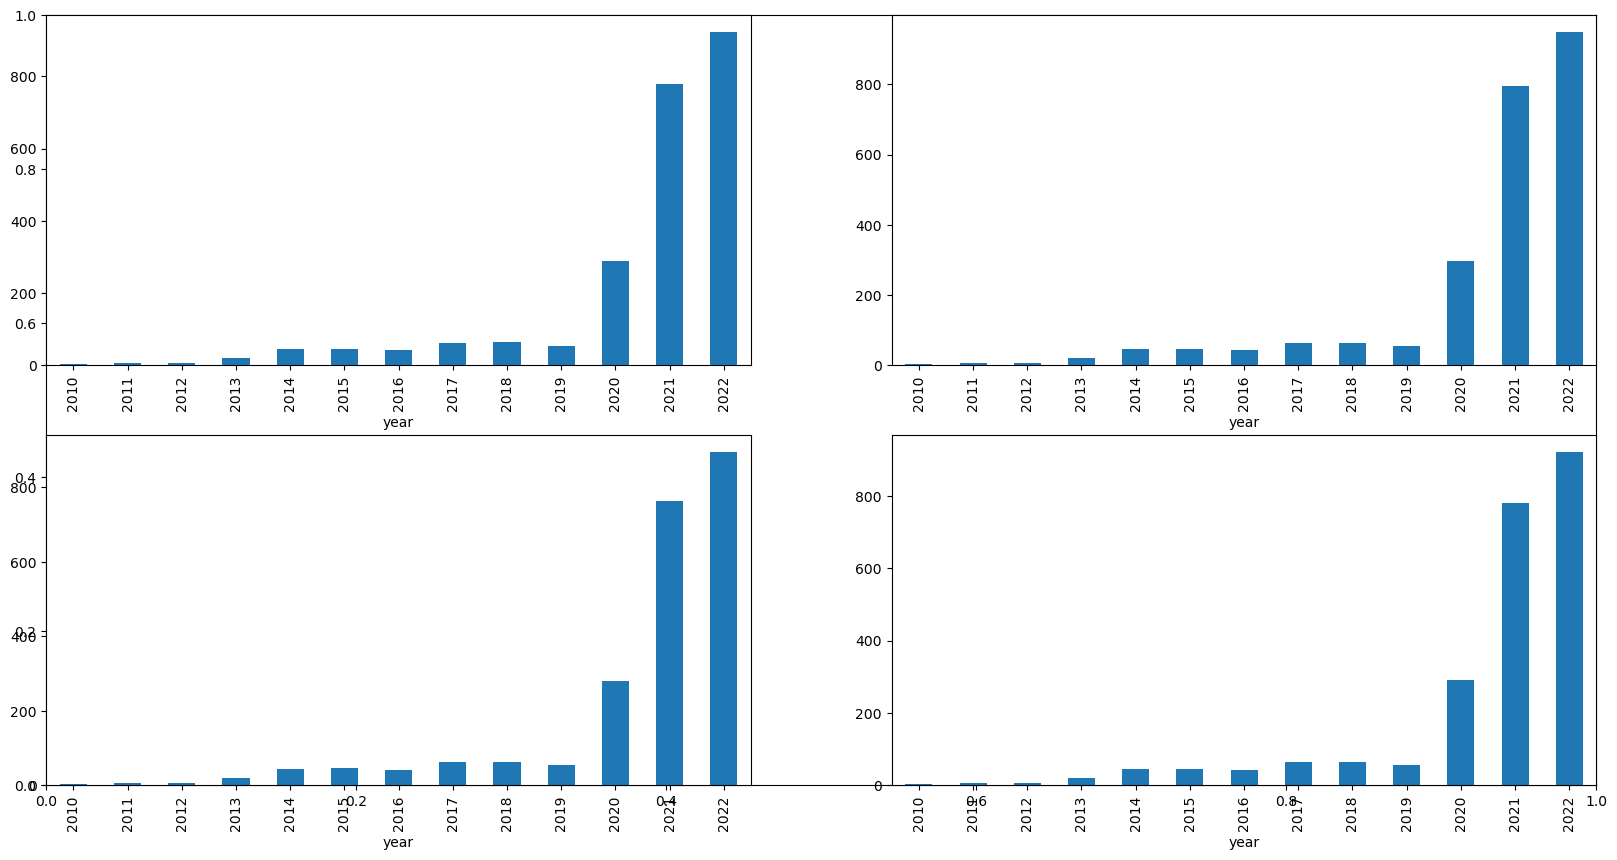

In [15]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2,2, i+1)
    data_grouped[col].plot.bar()
plt.show()

In [16]:
df.drop('Date', axis=1).groupby('is_quaterly_end').mean()

,Open,High,Low,Close,Volume,day,month,year
is_quaterly_end,,,,,,,,
0,136.474690,139.523037,133.361644,136.531872,3.194378e+07,15.701987,6.124300,2015.855833
1,143.073168,146.216652,139.506757,143.171146,3.007048e+07,15.736153,7.489426,2015.852971


* as seen above price are higher in the quartely end month as compared to others
* The volume of trades are lowere in the month which are quartely end month

In [17]:
df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df ['Low'] - df['High']
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df.head()


,Date,Open,High,Low,Close,Volume,day,month,year,is_quaterly_end,open-close,low-high,Target
0,2010-06-29,3.800,5.000,3.508,4.778,93831500,29,6,2010,1,-0.978,-1.492,0
1,2010-06-30,5.158,6.084,4.660,4.766,85935500,30,6,2010,1,0.392,-1.424,0
2,2010-07-01,5.000,5.184,4.054,4.392,41094000,1,7,2010,0,0.608,-1.130,0
3,2010-07-02,4.600,4.620,3.742,3.840,25699000,2,7,2010,0,0.760,-0.878,0
4,2010-07-06,4.000,4.000,3.166,3.222,34334500,6,7,2010,0,0.778,-0.834,0


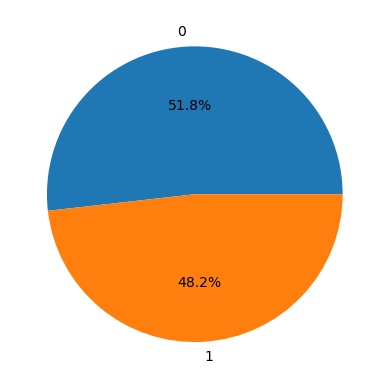

In [18]:
plt.pie(df['Target'].value_counts().values,
        labels=[0,1], autopct='%1.1f%%')
plt.show()

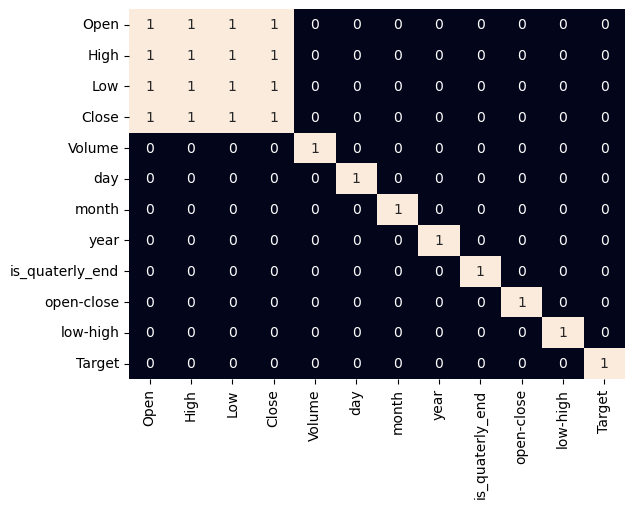

In [20]:
# looking for correlated features

sb.heatmap(df.drop('Date', axis=1).corr() > 0.9, annot=True, cbar = False)
plt.show()

## Data splitting and Normalization

In [25]:
features = df[['open-close', 'low-high', 'is_quaterly_end']]
target = df['Target']
scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_valid, Y_train, Y_valid = train_test_split(features, target, test_size=0.1, random_state=2022)
print(X_train.shape, X_valid.shape)


(2660, 3) (296, 3)


In [30]:
X_valid

array([[ 3.80023709e-03,  4.42848354e-01, -7.11237218e-01],
       [ 1.77911816e-01,  3.22323981e-01, -7.11237218e-01],
       [ 2.06963950e-02,  3.50137281e-01, -7.11237218e-01],
       [ 7.44751982e-02,  3.38869258e-01, -7.11237218e-01],
       [ 7.99273785e+00, -5.89886489e+00, -7.11237218e-01],
       [-1.24527194e+00, -5.66845122e-01, -7.11237218e-01],
       [ 3.59418764e-03,  4.43418883e-01,  1.40600066e+00],
       [-7.53248263e-03,  4.36144635e-01, -7.11237218e-01],
       [-9.28369547e-02,  3.34305095e-01, -7.11237218e-01],
       [ 2.29624238e-02,  3.53417896e-01, -7.11237218e-01],
       [-5.43057076e-02,  3.90644928e-01,  1.40600066e+00],
       [-4.85383979e-03,  4.38712017e-01, -7.11237218e-01],
       [ 5.01614662e-02,  3.72530768e-01,  1.40600066e+00],
       [-9.18087822e-03,  4.36002003e-01, -7.11237218e-01],
       [ 2.48380934e-01,  2.72117551e-01, -7.11237218e-01],
       [-1.69487762e-01,  2.78250669e-01, -7.11237218e-01],
       [-7.12038373e-03,  4.41136766e-01

In [31]:
models = [LogisticRegression(), SVC(kernel='poly', probability=True), XGBClassifier()]

for i in range(3):
    models[i].fit(X_train, Y_train)
    
    print(f'{models[i]} : ')
    print('Training Accuracy : ', metrics.roc_auc_score(
    Y_train, models[i].predict_proba(X_train)[:,1]))
    print('Validation Accuracy : ', metrics.roc_auc_score(
    Y_valid, models[i].predict_proba(X_valid)[:,1]))
    print()

LogisticRegression() : 
Training Accuracy :  0.5145097983728333
Validation Accuracy :  0.5385531135531135

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.49962730810045985
Validation Accuracy :  0.5403388278388278

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Traini

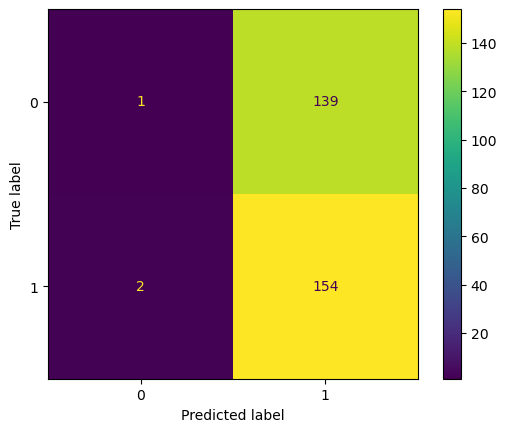

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[0], X_valid, Y_valid)
plt.show()

